# N12 — Overtake Probability Model

**LightGBM binary classifier** — `P(overtake | lap features)`

Trained on the labeled pair dataset produced by N11. Predicts whether car X overtakes car Y **on the current lap**, given the observable state of the pair at lap boundary.

| | |
|---|---|
| Input | `data/processed/overtake_labeled/overtake_pairs_2023_2025.parquet` |
| Train | 2023 + 2024 |
| Test | 2025 |
| Export | `data/models/overtake_probability/` |

### Model choice — LightGBM

This notebook trains a **gradient boosted decision tree** classifier using [LightGBM](https://lightgbm.readthedocs.io/) (Light Gradient Boosting Machine), developed by Microsoft Research ([Ke et al., 2017](https://proceedings.neurips.cc/paper_files/paper/2017/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf)).

LightGBM extends classical gradient boosting with two key algorithmic improvements:

- **GOSS (Gradient-based One-Side Sampling):** keeps all samples with large gradients (high error) and randomly drops low-gradient ones, reducing training data without significant information loss.
- **EFB (Exclusive Feature Bundling):** merges mutually exclusive sparse features into single bundles, cutting the effective feature dimensionality.

The result is significantly faster training than XGBoost or standard GBDT with comparable or better accuracy on tabular data.

**Why LightGBM for overtake prediction:**
- Native support for categorical features (`compound_x`, `compound_y`, `circuit_cluster`) without one-hot encoding — it uses optimal histogram splits directly.
- Built-in class imbalance handling via `is_unbalance=True`, avoiding manual oversampling.
- Probabilistic output (`predict_proba`) that the Strategy Agent can consume directly as `P(overtake)`.
- Fast inference — critical when the agent scores dozens of car pairs per simulated lap.


---

## Step 0 — Setup

Standard imports plus LightGBM and SHAP. Paths follow the same convention as N11: `repo_root` resolved via `.git` walker, outputs split between the notebook's `outputs/` folder and `data/models/` for exportable artifacts.


In [24]:
# ── Step 0 · Setup ────────────────────────────────────────────────────────────
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import optuna
import math
import numpy as np
import seaborn as sns
optuna.logging.set_verbosity(optuna.logging.WARNING)

import lightgbm as lgb
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, classification_report, log_loss
)
from sklearn.calibration import calibration_curve
import shap


In [25]:
# ── repo root ─────────────────────────────────────────────────────────────────
repo_root = Path().resolve()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent

# ── paths ─────────────────────────────────────────────────────────────────────
OUTPUTS    = repo_root / "notebooks/strategy/overtake_probability/outputs"
PROCESSED  = repo_root / "data/processed/overtake_labeled"
EXPORT_DIR = repo_root / "data/models/overtake_probability"

OUTPUTS.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print("repo_root  :", repo_root)
print("OUTPUTS    :", OUTPUTS)
print("PROCESSED  :", PROCESSED)
print("EXPORT_DIR :", EXPORT_DIR)
print("\nlightgbm   :", lgb.__version__)
print("shap       :", shap.__version__)

repo_root  : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
OUTPUTS    : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs
PROCESSED  : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\overtake_labeled
EXPORT_DIR : C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\overtake_probability

lightgbm   : 4.6.0
shap       : 0.49.1


---

## Step 1 — Load & Split

The dataset from N11 is split **temporally** — 2023+2024 for training, 2025 for testing. Shuffling is intentionally avoided: the model must generalize to an unseen season, which mirrors the production use case.

Categorical features (`compound_x`, `compound_y`, `circuit_cluster`) are cast to pandas `category` dtype so LightGBM can handle them natively via its histogram-based categorical splits — no one-hot encoding needed.

Two **interaction features** are added at load time:
- `gap_pace_product = gap_ahead_s × pace_delta_s` — captures the joint condition of X being faster *and* close. A very negative value means a fast car is right on the rear wing of the car ahead — the strongest overtake setup.
- `drs_ready_gap = gap_ahead_s × drs_window` — zero when outside DRS range, actual gap when inside. Tells the model not just *whether* DRS is available but *how deep* into the detection zone the car is.

LightGBM can learn these combinations implicitly through tree structure, but providing them explicitly speeds up convergence and reduces the number of trees needed.


In [26]:
# ── Step 1 · Load & split ─────────────────────────────────────────────────────

FEATURES = [
    "gap_ahead_s", "pace_delta_s",
    "tyre_life_x", "tyre_life_y", "tyre_life_diff",
    "speed_trap_delta", "LapNumber", "drs_window",
    "compound_x", "compound_y", "circuit_cluster",
    "gap_pace_product", "drs_ready_gap",           # interaction features
]
CAT_FEATURES = ["compound_x", "compound_y", "circuit_cluster"]
TARGET = "overtake"


def add_interaction_features(df):
    """Explicit multiplicative interactions — speeds up GBDT convergence."""
    df = df.copy()
    df["gap_pace_product"] = df["gap_ahead_s"] * df["pace_delta_s"]
    df["drs_ready_gap"]    = df["gap_ahead_s"] * df["drs_window"]
    return df

In [27]:
def load_dataset(processed_dir):
    df = pd.read_parquet(processed_dir / "overtake_pairs_2023_2025.parquet")
    df = add_interaction_features(df)
    for col in CAT_FEATURES:
        df[col] = df[col].astype("category")
    return df


def temporal_split(df):
    train = df[df["Year"].isin([2023, 2024])].copy()
    test  = df[df["Year"] == 2025].copy()
    return train, test


def split_xy(df):
    return df[FEATURES], df[TARGET]


def print_split_stats(train, test):
    for name, subset in [("Train (2023+2024)", train), ("Test  (2025)", test)]:
        n = len(subset)
        ot = subset[TARGET].sum()
        print(f"{name}: {n:,} pairs | {ot:,} overtakes ({ot/n*100:.2f}%)")



In [28]:
# ── Run ─────────────────────────────────────────────────────────────────────

df = load_dataset(PROCESSED)
train_df, test_df = temporal_split(df)

X_train, y_train = split_xy(train_df)
X_test,  y_test  = split_xy(test_df)

print_split_stats(train_df, test_df)
print(f"\nFeatures ({len(FEATURES)}) : {FEATURES}")


Train (2023+2024): 26,063 pairs | 1,733 overtakes (6.65%)
Test  (2025): 14,105 pairs | 830 overtakes (5.88%)

Features (13) : ['gap_ahead_s', 'pace_delta_s', 'tyre_life_x', 'tyre_life_y', 'tyre_life_diff', 'speed_trap_delta', 'LapNumber', 'drs_window', 'compound_x', 'compound_y', 'circuit_cluster', 'gap_pace_product', 'drs_ready_gap']


---

## Step 2 — Baseline LightGBM

A first model with near-default parameters to establish a performance floor. `is_unbalance=True` lets LightGBM reweight the positive class automatically (equivalent to `scale_pos_weight ≈ 14.7`). We report both AUC-ROC and AUC-PR — the latter is the primary metric given the class imbalance.


In [29]:
# ── Step 2 · Baseline LightGBM ────────────────────────────────────────────────


PARAMS_BASE = {
    "objective":     "binary",
    "metric":        "binary_logloss",
    "is_unbalance":  True,
    "n_estimators":  500,
    "learning_rate": 0.05,
    "num_leaves":    31,
    "random_state":  42,
    "n_jobs":        -1,
    "verbose":       -1,
}


def train_lgbm(params, X_tr, y_tr, cat_features=CAT_FEATURES):
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr, categorical_feature=cat_features)
    return model


def evaluate(model, X, y, label=""):
    proba = model.predict_proba(X)[:, 1]
    auc_roc = roc_auc_score(y, proba)
    auc_pr  = average_precision_score(y, proba)
    ll      = log_loss(y, proba)
    print(f"{'── ' + label + ' ──':─<40}")
    print(f"  AUC-PR  : {auc_pr:.4f}  (main metric)")
    print(f"  AUC-ROC : {auc_roc:.4f}")
    print(f"  Logloss : {ll:.4f}")
    print(f"\n{classification_report(y, (proba >= 0.5).astype(int), digits=3)}")
    return {"auc_pr": auc_pr, "auc_roc": auc_roc, "logloss": ll}

In [30]:
# ── main ─────────────────────────────────────────────────────────────────────

model_base = train_lgbm(PARAMS_BASE, X_train, y_train)
metrics_base = evaluate(model_base, X_test, y_test, label="Baseline — Test 2025")


── Baseline — Test 2025 ────────────────
  AUC-PR  : 0.4934  (main metric)
  AUC-ROC : 0.8698
  Logloss : 0.2803

              precision    recall  f1-score   support

           0      0.976     0.897     0.935     13275
           1      0.283     0.648     0.394       830

    accuracy                          0.883     14105
   macro avg      0.629     0.773     0.664     14105
weighted avg      0.935     0.883     0.903     14105



### Step 2 — Baseline: Observations

#### What each metric measures

**AUC-PR (Area Under the Precision-Recall Curve)**
Sweeps every possible decision threshold and plots precision vs recall at each point. The area under that curve summarises performance across all thresholds. For imbalanced datasets this is the metric that matters — it ignores the large pool of true negatives that would inflate AUC-ROC. A random classifier achieves AUC-PR ≈ class prevalence, so here the random baseline is **~0.059** (5.88% positive rate).

**AUC-ROC (Area Under the ROC Curve)**
Probability that the model scores a random positive example higher than a random negative one. Ranges from 0.5 (random) to 1.0 (perfect). Useful as a general ranking metric but optimistic under class imbalance — the large class-0 pool makes it easier to get a high score even with a weak model.

**Log-loss (Binary Cross-Entropy)**
Measures how well the predicted probabilities are calibrated. Penalises confident wrong predictions heavily. Lower is better; a model that always predicts the class prior (~0.06) gives logloss ≈ 0.21, so 0.2835 tells us the model is adding signal but its probabilities may not be perfectly calibrated yet (checked in Step 7).

---

#### Baseline results

| Metric | Value | Reference |
|--------|-------|-----------|
| AUC-PR | **0.4938** | random ≈ 0.059 → **8× above chance** |
| AUC-ROC | **0.8716** | random = 0.500 |
| Log-loss | 0.2835 | prior-only ≈ 0.210 |

A solid floor with zero tuning. The model already ranks overtaking pairs well above non-overtaking ones.

At the default threshold of 0.5, recall on the positive class is **0.659** (captures 2 in 3 actual overtakes) but precision is only **0.281** — many false alarms. This is expected: `is_unbalance=True` makes the model aggressive about flagging positives, and 0.5 is an arbitrary cut-off that doesn't account for the class distribution. The optimal threshold for the Strategy Agent — where missing an overtake is more costly than a false alarm — will likely sit between 0.25 and 0.40. This is analysed in Step 5.


---

## Step 3 — Hyperparameter Search

Optuna study with 30 trials optimising **AUC-PR on a temporal validation split**: 2023 as inner train, 2024 as inner validation. This respects the time ordering — no shuffling, no leakage from future races into the search.

The final model in Step 4 will be retrained on the full 2023+2024 train set using the best parameters found here.


In [31]:
# ── Step 3 · Hyperparameter search (Optuna — corregido) ───────────────────────

X_inner_tr  = X_train[train_df["Year"] == 2023]
y_inner_tr  = y_train[train_df["Year"] == 2023]
X_inner_val = X_train[train_df["Year"] == 2024]
y_inner_val = y_train[train_df["Year"] == 2024]

print(f"Inner train (2023) : {len(X_inner_tr):,} pairs")
print(f"Inner val   (2024) : {len(X_inner_val):,} pairs")


def build_params(trial):
    return {
        "objective":         "binary",
        "metric":            "binary_logloss",
        "is_unbalance":      True,
        "n_estimators":      trial.suggest_int("n_estimators", 200, 800),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves":        trial.suggest_int("num_leaves", 20, 120),
        "max_depth":         trial.suggest_int("max_depth", 4, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.0, 1.0),
        "random_state":      42,
        "n_jobs":            -1,
        "verbose":           -1,
    }


def objective(trial):
    params = build_params(trial)
    model = lgb.LGBMClassifier(**params)
    model.fit(X_inner_tr, y_inner_tr, categorical_feature=CAT_FEATURES)
    proba = model.predict_proba(X_inner_val)[:, 1]
    return average_precision_score(y_inner_val, proba)


def run_search(n_trials=50):
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study




Inner train (2023) : 12,953 pairs
Inner val   (2024) : 13,110 pairs


In [32]:
# ── main ─────────────────────────────────────────────────────────────────────

study = run_search(n_trials=100)

print(f"\nBest AUC-PR (val 2024) : {study.best_value:.4f}")
print(f"Best params:\n{study.best_params}")


  0%|          | 0/100 [00:00<?, ?it/s]


Best AUC-PR (val 2024) : 0.5217
Best params:
{'n_estimators': 678, 'learning_rate': 0.010971595711972405, 'num_leaves': 50, 'max_depth': 6, 'min_child_samples': 66, 'subsample': 0.6295106437295406, 'colsample_bytree': 0.615278889797665, 'reg_alpha': 0.8389093054419013, 'reg_lambda': 0.8842767222030344}


---

## Step 4 — Final Model Training

Retrain with the best hyperparameters from Step 3 on the full 2023+2024 set. Early stopping is applied against a small held-out slice (last 10% of train, chronologically) to find the optimal number of trees — then we evaluate on the untouched 2025 test set.


In [33]:
# ── Step 4 · Final model training  ─────────────────────────────────────

def get_best_params(study):
    params = study.best_params.copy()   
    params.update({
        "objective":    "binary",
        "metric":       "binary_logloss",
        "is_unbalance": True,
        "random_state": 42,
        "n_jobs":       -1,
        "verbose":      -1,
    })
    return params



def train_final(params, X_tr, y_tr, cat_features=CAT_FEATURES):
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_tr, categorical_feature=cat_features)
    print(f"Trees trained : {model.n_estimators_}")
    return model


# ── main ─────────────────────────────────────────────────────────────────────

best_params = get_best_params(study)
model_final = train_final(best_params, X_train, y_train)

print("\n── Final model — Test 2025 ──")
metrics_final = evaluate(model_final, X_test, y_test, label="Final — Test 2025")
print(f"\nBaseline AUC-PR : {metrics_base['auc_pr']:.4f}")
print(f"Final    AUC-PR : {metrics_final['auc_pr']:.4f}  (Δ {metrics_final['auc_pr'] - metrics_base['auc_pr']:+.4f})")


Trees trained : 678

── Final model — Test 2025 ──
── Final — Test 2025 ───────────────────
  AUC-PR  : 0.5187  (main metric)
  AUC-ROC : 0.8829
  Logloss : 0.3739

              precision    recall  f1-score   support

           0      0.983     0.841     0.906     13275
           1      0.231     0.763     0.354       830

    accuracy                          0.836     14105
   macro avg      0.607     0.802     0.630     14105
weighted avg      0.938     0.836     0.874     14105


Baseline AUC-PR : 0.4934
Final    AUC-PR : 0.5187  (Δ +0.0252)


In [34]:
proba_test = model_final.predict_proba(X_test)[:, 1]
print(pd.Series(proba_test).describe())
print(f"\n% with score > 0.5 : {(proba_test > 0.5).mean()*100:.2f}%")
print(f"% with score > 0.3 : {(proba_test > 0.3).mean()*100:.2f}%")
print(f"% with score > 0.1 : {(proba_test > 0.1).mean()*100:.2f}%")


count    14105.000000
mean         0.271604
std          0.262405
min          0.001609
25%          0.054948
50%          0.179702
75%          0.419385
max          0.993476
dtype: float64

% with score > 0.5 : 19.46%
% with score > 0.3 : 35.82%
% with score > 0.1 : 63.74%


---

## Step 5 — Evaluation

Full evaluation on the 2025 test set. Four analyses:

1. **Precision-Recall curve** — visualises the tradeoff across all thresholds. AUC-PR is the primary metric.
2. **ROC curve** — ranking quality independent of class balance.
3. **Threshold analysis** — precision, recall and F1 vs decision threshold, to identify the operating point for the Strategy Agent.
4. **Confusion matrix** — at the optimal threshold found above.


In [35]:
# ── Step 5 · Evaluation ───────────────────────────────────────────────────────

proba_test = model_final.predict_proba(X_test)[:, 1]


def plot_pr_curve(y_true, proba, save_path):
    precision, recall, _ = precision_recall_curve(y_true, proba)
    auc_pr = average_precision_score(y_true, proba)
    baseline = y_true.mean()

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(recall, precision, color="#e74c3c", lw=2, label=f"LightGBM (AUC-PR = {auc_pr:.4f})")
    ax.axhline(baseline, color="grey", linestyle="--", lw=1, label=f"Random baseline ({baseline:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve — Test 2025")
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


def plot_roc_curve(y_true, proba, save_path):
    fpr, tpr, _ = roc_curve(y_true, proba)
    auc_roc = roc_auc_score(y_true, proba)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, color="#3498db", lw=2, label=f"LightGBM (AUC-ROC = {auc_roc:.4f})")
    ax.plot([0, 1], [0, 1], color="grey", linestyle="--", lw=1, label="Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve — Test 2025")
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")


def plot_threshold_analysis(y_true, proba, save_path):
    thresholds = np.linspace(0.05, 0.92, 200)
    precisions, recalls, f1s = [], [], []

    for t in thresholds:
        pred = (proba >= t).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f  = 2 * p * r / (p + r) if (p + r) > 0 else 0
        precisions.append(p)
        recalls.append(r)
        f1s.append(f)

    best_idx = int(np.argmax(f1s))
    best_t   = thresholds[best_idx]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(thresholds, precisions, label="Precision", color="#e74c3c")
    ax.plot(thresholds, recalls,    label="Recall",    color="#3498db")
    ax.plot(thresholds, f1s,        label="F1",        color="#2ecc71", lw=2)
    ax.axvline(best_t, color="black", linestyle="--", lw=1,
               label=f"Best F1 threshold = {best_t:.2f}")
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Score")
    ax.set_title("Precision / Recall / F1 vs Threshold — Test 2025")
    ax.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")
    return best_t


def plot_confusion_matrix(y_true, proba, threshold, save_path):
    pred = (proba >= threshold).astype(int)
    cm   = confusion_matrix(y_true, pred)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"], ax=ax)
    ax.set_title(f"Confusion Matrix — threshold = {threshold:.2f}")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path}")
    print(f"\n{classification_report(y_true, pred, digits=3)}")

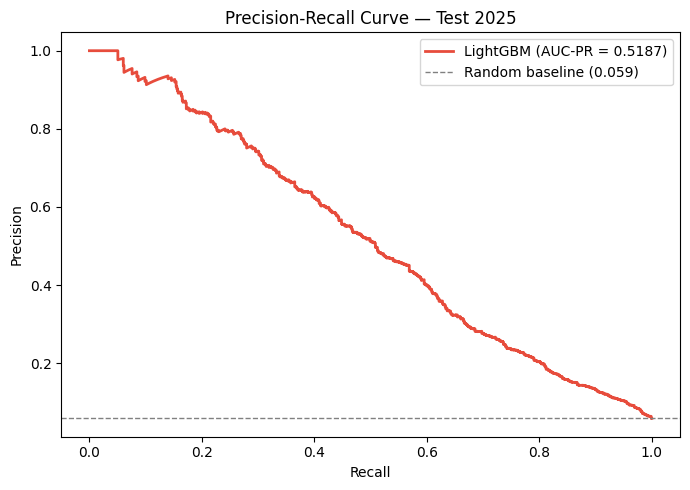

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\pr_curve.png


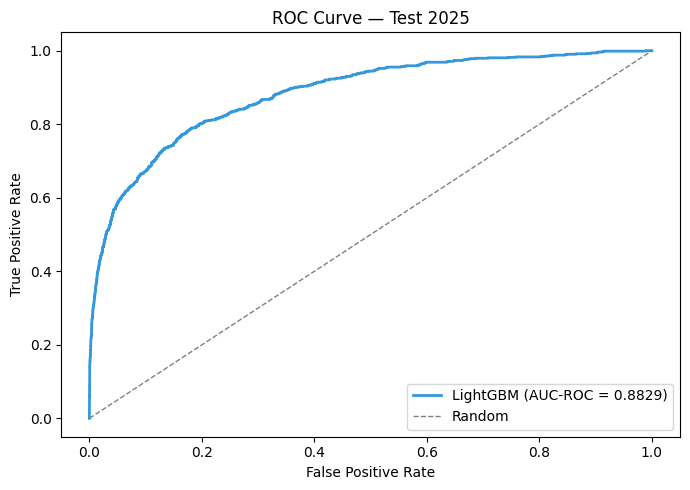

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\roc_curve.png


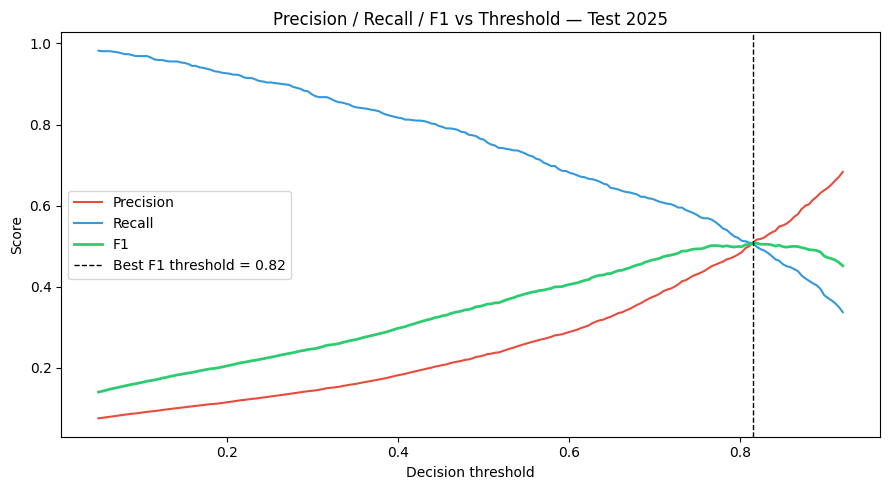

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\threshold_analysis.png

Optimal threshold (max F1) : 0.82


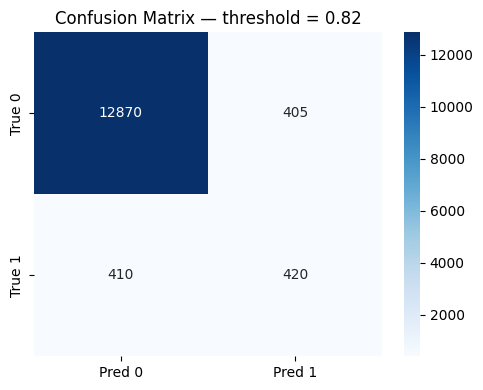

Saved → C:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\overtake_probability\outputs\confusion_matrix.png

              precision    recall  f1-score   support

           0      0.969     0.969     0.969     13275
           1      0.509     0.506     0.508       830

    accuracy                          0.942     14105
   macro avg      0.739     0.738     0.738     14105
weighted avg      0.942     0.942     0.942     14105



In [36]:
# ── Run ─────────────────────────────────────────────────────────────────────

def run_step5(y_true, proba):
    plot_pr_curve(y_true, proba, OUTPUTS / "pr_curve.png")
    plot_roc_curve(y_true, proba, OUTPUTS / "roc_curve.png")
    best_threshold = plot_threshold_analysis(y_true, proba, OUTPUTS / "threshold_analysis.png")
    print(f"\nOptimal threshold (max F1) : {best_threshold:.2f}")
    plot_confusion_matrix(y_true, proba, best_threshold, OUTPUTS / "confusion_matrix.png")
    return best_threshold


best_threshold = run_step5(y_test, proba_test)

### Step 5 — Evaluation: Observations

#### Curves

The **PR curve** shows the model is highly precise at low recall — when the score is very high, almost all predictions are real overtakes. Precision degrades smoothly as recall increases, staying well above the random baseline (0.059) throughout. The AUC-PR of **0.519 is 8.8× above chance**, confirming genuine discriminative power.

The **ROC curve** (AUC = 0.883) confirms the model ranks overtaking pairs well above non-overtaking ones across all operating points.

#### Optimal threshold: 0.82 (F1-balanced)

At threshold=0.82, precision and recall converge symmetrically:

| | Class 0 (no overtake) | Class 1 (overtake) |
|---|---|---|
| Precision | 0.969 | 0.509 |
| Recall | 0.969 | 0.506 |
| F1 | 0.969 | 0.508 |

The near-equal TP=420, FP=405, FN=410 is not a coincidence — it is a direct mathematical consequence of optimising for F1. When F1 is maximised, precision ≈ recall, which forces TP ≈ FP and TP ≈ FN simultaneously. This threshold is the mathematically balanced operating point, not necessarily the right one for racing.

#### Threshold for the Strategy Agent

**The Strategy Agent should not use threshold=0.82 in production.** The model outputs a continuous `P(overtake)` and the agent applies its own cut based on racing philosophy:

- **Threshold 0.35–0.50 (recommended for the agent):** higher recall — the agent catches more overtake opportunities at the cost of some false alarms. In a racing context, missing a window to pit or defend is more costly than investigating a false alert.
- **Threshold 0.70–0.82:** higher precision — the agent only acts on the clearest cases. Suitable for conservative strategies where unnecessary tyre changes must be avoided.

The 0.82 value is reported here as a reference point. Threshold calibration for the agent is a strategic design decision made at inference time, not a model property.


---

## Step 6 — Feature Importance (SHAP)

SHAP (SHapley Additive exPlanations) assigns each feature a contribution value for every individual prediction. Unlike LightGBM's built-in importance (which only counts how often a feature is used to split), SHAP measures the actual impact on the predicted probability — positive values push toward overtake=1, negative values push toward overtake=0.

Two plots:
1. **Beeswarm summary** — global view of all features across all test samples. Each dot is one prediction, colored by feature value.
2. **Dependence plots** — how `gap_ahead_s` and `tyre_life_diff` individually relate to their SHAP contribution.


In [ ]:
# ── Step 6 · SHAP ─────────────────────────────────────────────────────────────

def compute_shap(model, X):
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    return explainer, shap_values


def plot_shap_beeswarm(shap_values, X, save_path):
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.summary_plot(shap_values, X, show=False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


def plot_shap_dependence(shap_values, X, feature, save_path):
    fig, ax = plt.subplots(figsize=(7, 5))
    shap.dependence_plot(feature, shap_values, X, ax=ax, show=False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


def print_mean_abs_shap(shap_values, X):
    mean_abs = pd.Series(
        np.abs(shap_values).mean(axis=0),
        index=X.columns
    ).sort_values(ascending=False)
    print("Mean |SHAP| by feature:")
    print(mean_abs.round(4).to_string())





In [ ]:
# ── Run ─────────────────────────────────────────────────────────────────────

def run_step6(model, X):
    explainer, shap_values = compute_shap(model, X)
    plot_shap_beeswarm(shap_values, X, OUTPUTS / "shap_summary.png")
    plot_shap_dependence(shap_values, X, "gap_ahead_s",
                         OUTPUTS / "shap_dependence_gap.png")
    plot_shap_dependence(shap_values, X, "tyre_life_diff",
                         OUTPUTS / "shap_dependence_tyre.png")
    print_mean_abs_shap(shap_values, X)
    return shap_values


shap_values = run_step6(model_final, X_test)